In [132]:
# !pip install -q opencv-python-headless torchvision torch matplotlib

In [133]:
import math
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.ops as tv_ops
import torchvision.models as tvm
from torchvision import transforms

# DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = 'cpu'
EMBED_DIM = 512   # projection head output dimension
print(f'Device: {DEVICE}')

Device: cpu


In [134]:
PATTERN_PATH = './BOM_Data/Pattern4_2.png'   # <- path to your pattern / symbol image
DRAWING_PATH = './BOM_Data/4.png'
ROTATE = True
# Detection hyper-parameters
PATTERN_SIZE         = 224    # pattern resize target (do NOT pad)
SIMILARITY_THRESHOLD = 0.80   # cosine similarity cutoff
IOU_THRESHOLD        = 0.30   # Soft-NMS sigma
SCALES               = [0.75, 1.0, 1.25]   # 
STRIDE_FACTOR        = 0.50   # was 0.25 → 4× fewer windows
SCALE_SIGMA          = 0.50   # Gaussian scale-penalty width
MAX_DETECTIONS       = 40     # hard cap on final bounding boxes


In [135]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)


def crop_to_content(img: np.ndarray, pad: int = 4, threshold: int = 200) -> np.ndarray:
    gray = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY_INV)
    coords = cv2.findNonZero(binary)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    x1 = max(0, x - pad);  y1 = max(0, y - pad)
    x2 = min(img.shape[1], x + w + pad)
    y2 = min(img.shape[0], y + h + pad)
    return img[y1:y2, x1:x2]


def pad_to_multiple(img: np.ndarray, multiple: int = 32,
                    pad_value: int = 255) -> np.ndarray:
    h, w  = img.shape[:2]
    new_h = math.ceil(h / multiple) * multiple
    new_w = math.ceil(w / multiple) * multiple
    fill  = (pad_value,) * 3 if img.ndim == 3 else pad_value
    return cv2.copyMakeBorder(img, 0, new_h - h, 0, new_w - w,
                              cv2.BORDER_CONSTANT, value=fill)



def resize_preserve_ar(img: np.ndarray, target: int = PATTERN_SIZE,
                       pad_value: int = 255) -> np.ndarray:
    h, w = img.shape[:2]
    scale = min(target / w, target / h)
    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    if img.ndim == 3:
        canvas = np.full((target, target, img.shape[2]), pad_value, dtype=img.dtype)
    else:
        canvas = np.full((target, target), pad_value, dtype=img.dtype)
    y_off = (target - new_h) // 2
    x_off = (target - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas

print(f'resize_preserve_ar: target={PATTERN_SIZE}, preserves aspect ratio, '
      f'uses INTER_CUBIC for upscaling')


def to_tensor(img_rgb: np.ndarray) -> torch.Tensor:
    resized = resize_preserve_ar(img_rgb, target=PATTERN_SIZE)
    return preprocess(resized).unsqueeze(0)


def crops_to_batch(bom_bgr: np.ndarray,
                   boxes: list[tuple[int, int, int, int]],
                   size: int = PATTERN_SIZE) -> torch.Tensor:
    frames = []
    valid_indices = []
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        crop = bom_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        resized  = resize_preserve_ar(crop_rgb, target=size)
        # HWC uint8 → CHW float32 in [0,1]
        t = torch.from_numpy(resized).permute(2, 0, 1).float().div_(255.0)
        frames.append(t)
        valid_indices.append(i)

    if not frames:
        return None, []

    # Stack → [N, 3, H, W], move to GPU in one transfer
    batch = torch.stack(frames, dim=0).to(DEVICE, non_blocking=True)
    # Normalise on GPU (elementwise broadcast, no Python loop)
    batch = (batch - _MEAN) / _STD
    return batch, valid_indices


resize_preserve_ar: target=224, preserves aspect ratio, uses INTER_CUBIC for upscaling


BOM size after padding : 1024 x 1536


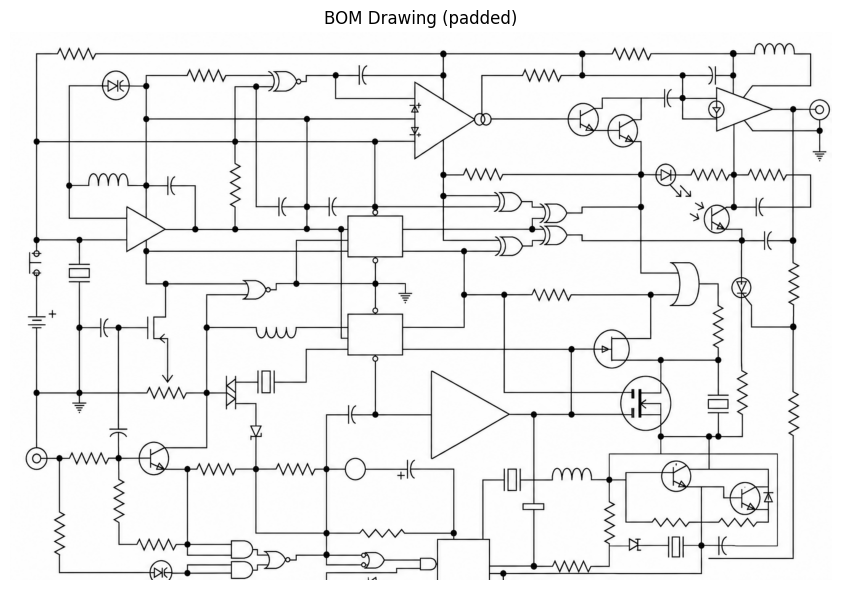

In [136]:
drawing_img_cv = cv2.imread(DRAWING_PATH, cv2.IMREAD_GRAYSCALE)
if drawing_img_cv is None:
    raise FileNotFoundError(f'BOM image not found at: {DRAWING_PATH}')

# Pad so dimensions are multiples of 32 (ensures H/32 and W/32 are integers)
drawing_padded = pad_to_multiple(drawing_img_cv, multiple=32, pad_value=255)
target_h, target_w = drawing_padded.shape[:2]

drawing_rgb = cv2.cvtColor(drawing_padded, cv2.COLOR_BGR2RGB)

print(f'BOM size after padding : {target_h} x {target_w}')

plt.figure(figsize=(10, 6))
plt.imshow(drawing_rgb)
plt.title('BOM Drawing (padded)')
plt.axis('off')
plt.tight_layout()
plt.show()


Pattern crop size  : 27 x 88 px  (aspect ratio: 3.26)
Pattern tensor     : torch.Size([1, 3, 224, 224])
AR-preserving scale: 2.55x
Effective size in 224×224 canvas: 224 x 68
⚠ Upscale factor 2.5x — consider using a higher-resolution pattern image


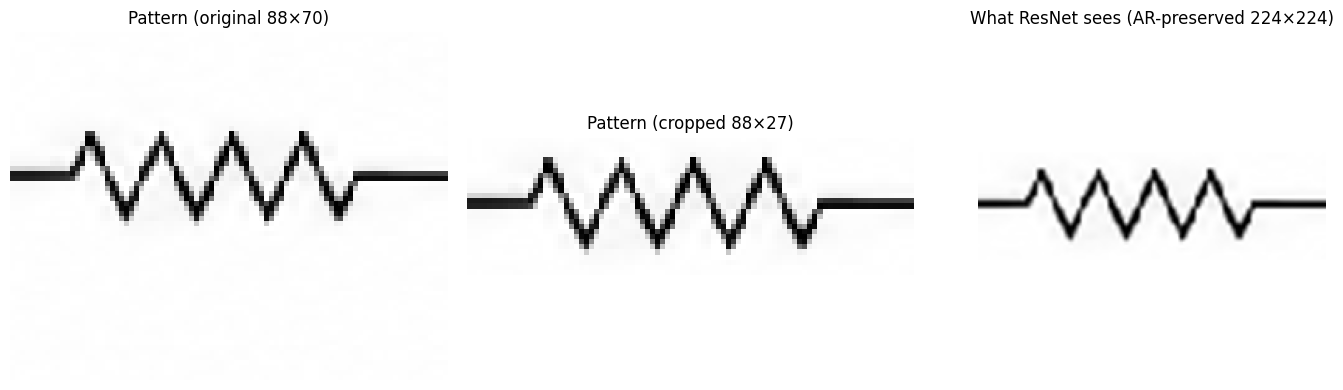

In [137]:
pattern_img_cv = cv2.imread(PATTERN_PATH, cv2.IMREAD_GRAYSCALE)
if pattern_img_cv is None:
    raise FileNotFoundError(f'Pattern image not found at: {PATTERN_PATH}')

pattern_cropped = crop_to_content(pattern_img_cv)           # tight crop
pattern_rgb     = cv2.cvtColor(pattern_cropped, cv2.COLOR_GRAY2RGB)
pattern_tensor  = to_tensor(pattern_rgb).to(DEVICE)         # resize + normalise

pat_h, pat_w = pattern_cropped.shape[:2]

# Diagnostic: show resize impact
scale_factor = min(PATTERN_SIZE / pat_w, PATTERN_SIZE / pat_h)
print(f'Pattern crop size  : {pat_h} x {pat_w} px  (aspect ratio: {pat_w/pat_h:.2f})')
print(f'Pattern tensor     : {pattern_tensor.shape}')
print(f'AR-preserving scale: {scale_factor:.2f}x')
print(f'Effective size in 224×224 canvas: {int(pat_w*scale_factor)} x {int(pat_h*scale_factor)}')
if scale_factor > 2.0:
    print(f'⚠ Upscale factor {scale_factor:.1f}x — consider using a higher-resolution pattern image')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(pattern_img_cv, cmap='gray')
axes[0].set_title(f'Pattern (original {pattern_img_cv.shape[1]}×{pattern_img_cv.shape[0]})')
axes[0].axis('off')
axes[1].imshow(pattern_cropped, cmap='gray')
axes[1].set_title(f'Pattern (cropped {pat_w}×{pat_h})')
axes[1].axis('off')
# Show what ResNet actually sees (AR-preserved)
ar_preview = resize_preserve_ar(pattern_rgb, target=PATTERN_SIZE)
axes[2].imshow(ar_preview)
axes[2].set_title(f'What ResNet sees (AR-preserved {PATTERN_SIZE}×{PATTERN_SIZE})')
axes[2].axis('off')
plt.tight_layout()
plt.show()


In [138]:
class ImageEncoder(nn.Module):
    """
    MobileNetV3-Small spatial feature extractor (optimized for CPU).

    spatial_features(x) -> [B, 576, H/32, W/32]
    forward(x)          -> [B, EMBED_DIM]  (L2-normalised global descriptor)
    """

    def __init__(self, embed_dim: int = EMBED_DIM):
        super().__init__()

        # Load pretrained MobileNetV3 Small for fast CPU inference
        backbone = tvm.mobilenet_v3_small(weights=tvm.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        self.trunk = backbone.features  # output: [B, 576, H/32, W/32]

        # Projection head: 576 -> embed_dim (used for the global descriptor only)
        self.head = nn.Sequential(
            nn.Linear(576, embed_dim * 2), nn.LayerNorm(embed_dim * 2),
            nn.GELU(), nn.Dropout(0.1),
            nn.Linear(embed_dim * 2, embed_dim), nn.LayerNorm(embed_dim),
        )

    def spatial_features(self, x: torch.Tensor) -> torch.Tensor:
        """Return [B, 576, H/32, W/32] — the raw convolutional feature map."""
        return self.trunk(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return [B, EMBED_DIM] L2-normalised global descriptor."""
        feats  = self.trunk(x)                # [B, 576, H_f, W_f]
        pooled = feats.mean(dim=(2, 3))       # [B, 576]  global avg pool
        return F.normalize(self.head(pooled), p=2, dim=-1)


In [139]:
from ast import If
def project_out(v, w_emb):
    dot = torch.sum(v * w_emb, dim=1, keepdim=True)
    v_proj = v - dot * w_emb
    return F.normalize(v_proj, p=2, dim=1)


def rotate_image(img_rgb: np.ndarray, angle_deg: float,
                 pad_value: int = 255) -> np.ndarray:
    """
    Rotate img_rgb by angle_deg (CCW) around its centre.
    Expands the canvas so no corners are clipped, fills with pad_value.
    """
    h, w = img_rgb.shape[:2]
    cx, cy = w / 2, h / 2
    M = cv2.getRotationMatrix2D((cx, cy), angle_deg, 1.0)

    cos_a = abs(M[0, 0]);  sin_a = abs(M[0, 1])
    new_w = int(h * sin_a + w * cos_a)
    new_h = int(h * cos_a + w * sin_a)
    M[0, 2] += new_w / 2 - cx
    M[1, 2] += new_h / 2 - cy

    rotated = cv2.warpAffine(
        img_rgb, M, (new_w, new_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(pad_value, pad_value, pad_value),
    )
    return rotated




# ─── Configuration ───────────────────────────────────────────────────────────
if ROTATE:
    # ROTATION_ANGLES = [0, 45, 90, 135, 180, 225, 270, 315]  
    ROTATION_ANGLES = [0,90,270]  
else:
    ROTATION_ANGLES = [0]   

model = ImageEncoder(embed_dim=EMBED_DIM).to(DEVICE)
model.eval()

white_patch  = np.ones((PATTERN_SIZE, PATTERN_SIZE, 3), dtype=np.uint8) * 255
white_tensor = preprocess(white_patch).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    white_embedding = model(white_tensor)    



query_vectors_list = []
angle_dimensions = {}   # angle → (crop_h, crop_w)

with torch.no_grad():

    for angle in ROTATION_ANGLES:
        if angle == 0:
            rotated_rgb = pattern_rgb
        else:
            rotated_rgb = rotate_image(pattern_rgb, angle)
        # Tight-crop the rotated pattern (remove rotation padding white space)
        rotated_gray = cv2.cvtColor(rotated_rgb, cv2.COLOR_RGB2GRAY)
        rotated_cropped = crop_to_content(rotated_gray, pad=4, threshold=200)
        rotated_cropped_rgb = cv2.cvtColor(rotated_cropped, cv2.COLOR_GRAY2RGB)

        t = to_tensor(rotated_cropped_rgb).to(DEVICE)
        raw_q = model(t)
        q     = project_out(raw_q, white_embedding)
        query_vectors_list.append(q)

        # Store the crop dimensions for this rotation angle
        angle_dimensions[angle] = (rotated_cropped.shape[0],
                                   rotated_cropped.shape[1])

        print(f'  {angle:3d}°  crop={rotated_cropped.shape[1]}×{rotated_cropped.shape[0]}  '
              f'L2={torch.norm(q, p=2).item():.4f}')

query_bank = torch.cat(query_vectors_list, dim=0)
print(f'\nBuilt query bank shape {query_bank.shape} for angles: {ROTATION_ANGLES}')


dimension_groups = {}   # (h, w) → list of angle indices into ROTATION_ANGLES
for idx, angle in enumerate(ROTATION_ANGLES):
    dims = angle_dimensions[angle]
    if dims not in dimension_groups:
        dimension_groups[dims] = []
    dimension_groups[dims].append(idx)

print(f'\nDimension groups: {len(dimension_groups)}')
for dims, indices in dimension_groups.items():
    angles_in_group = [ROTATION_ANGLES[i] for i in indices]
    print(f'  {dims[1]}×{dims[0]} → angles {angles_in_group}')


    0°  crop=88×27  L2=1.0000
   90°  crop=27×88  L2=1.0000
  270°  crop=26×88  L2=1.0000

Built query bank shape torch.Size([3, 512]) for angles: [0, 90, 270]

Dimension groups: 3
  88×27 → angles [0]
  27×88 → angles [90]
  26×88 → angles [270]


In [140]:
@torch.no_grad()
def sliding_window_detections_gpu(
    model: nn.Module,
    bom_bgr: np.ndarray,
    query_bank: torch.Tensor,
    angles: list,
    white_emb: torch.Tensor,
    dimension_groups: dict,
    scales: list[float],
    stride_factor: float,
    similarity_threshold: float,
    scale_sigma: float = SCALE_SIGMA,
    batch_size: int = 256,
) -> tuple[list, np.ndarray]:
    """
    GPU-batched multi-scale sliding window search with per-shape windows.

    Iterates over each dimension group (angles sharing the same crop shape),
    slides windows of the correct aspect ratio, and compares every crop
    against ALL query vectors via matrix multiplication.

    This fixes the aspect-ratio mismatch: vertical patterns are scanned
    with vertical windows, horizontal with horizontal, etc.
    """
    img_h, img_w = bom_bgr.shape[:2]
    score_canvas = np.zeros((img_h, img_w), dtype=np.float32)
    raw: list[dict] = []

    for (dim_h, dim_w), group_indices in dimension_groups.items():
        group_angles = [angles[i] for i in group_indices]
        print(f'\n  ─── Window shape: {dim_w}×{dim_h}  '
              f'(angles {group_angles}) ───')

        for s in scales:
            win_h    = max(16, int(dim_h * s))
            win_w    = max(16, int(dim_w * s))
            stride_h = max(4, int(win_h * stride_factor))
            stride_w = max(4, int(win_w * stride_factor))

            log_s   = math.log(s) if s > 0 else 0.0
            penalty = math.exp(-0.5 * (log_s / scale_sigma) ** 2)

            ys = list(range(0, img_h - win_h + 1, stride_h))
            xs = list(range(0, img_w - win_w + 1, stride_w))
            all_boxes = [(x, y, x + win_w, y + win_h) for y in ys for x in xs]

            for batch_start in range(0, len(all_boxes), batch_size):
                batch_boxes = all_boxes[batch_start : batch_start + batch_size]
                batch_tensor, valid_idx = crops_to_batch(bom_bgr, batch_boxes)
                if batch_tensor is None:
                    continue

                feats  = model.trunk(batch_tensor)
                pooled = feats.mean(dim=(2, 3))
                embs   = F.normalize(model.head(pooled), p=2, dim=1)
                embs   = project_out(embs, white_emb)

                # Compare against ALL query vectors at once
                # embs is [N, D], query_bank is [K, D]. Result is [N, K]
                scores_all = (embs @ query_bank.T).cpu().numpy()

                # For each window crop, find its best matching angle
                max_scores = scores_all.max(axis=1)      
                best_k     = scores_all.argmax(axis=1)   

                for local_i, orig_i in enumerate(valid_idx):
                    raw_score     = float(max_scores[local_i])
                    penalised     = raw_score * penalty
                    x1, y1, x2, y2 = batch_boxes[orig_i]
                    best_angle    = angles[best_k[local_i]]

                    score_canvas[y1:y2, x1:x2] = np.maximum(
                        score_canvas[y1:y2, x1:x2], raw_score)

                    if penalised >= similarity_threshold:
                        raw.append({'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                                    'score': round(penalised, 4),
                                    'angle': best_angle})

            print(f'    scale {s:.2f}  penalty={penalty:.3f}  '
                  f'win={win_h}×{win_w}  windows={len(all_boxes)}  '
                  f'candidates so far={len(raw)}')

    return raw, score_canvas


print('GPU-batched, rotation-invariant sliding window detector ready.')
print(f'Dimension groups: {len(dimension_groups)}  '
      f'(separate window shapes for correct aspect ratios)')
for dims, indices in dimension_groups.items():
    h, w = dims
    group_angles = [ROTATION_ANGLES[i] for i in indices]
    win_str = ', '.join(f'{int(h*s)}×{int(w*s)}' for s in SCALES)
    print(f'  {w}×{h} → angles {group_angles}  →  windows: {win_str}')
print(f'Stride factor     : {STRIDE_FACTOR}  (50% overlap)')
print(f'Scale penalty σ   : {SCALE_SIGMA}')


GPU-batched, rotation-invariant sliding window detector ready.
Dimension groups: 3  (separate window shapes for correct aspect ratios)
  88×27 → angles [0]  →  windows: 20×66, 27×88, 33×110
  27×88 → angles [90]  →  windows: 66×20, 88×27, 110×33
  26×88 → angles [270]  →  windows: 66×19, 88×26, 110×32
Stride factor     : 0.5  (50% overlap)
Scale penalty σ   : 0.5


In [141]:
def soft_nms(raw_detections: list,
             sigma: float = 0.50,
             score_threshold: float = SIMILARITY_THRESHOLD,
             max_detections: int = MAX_DETECTIONS) -> list:
    """
    Soft-NMS (Bodla et al. 2017) — decays overlapping scores by Gaussian.
    """
    if not raw_detections:
        return []

    dets = [dict(d) for d in raw_detections]
    dets.sort(key=lambda d: -d['score'])

    def iou(a, b) -> float:
        ix1 = max(a['x1'], b['x1']);  iy1 = max(a['y1'], b['y1'])
        ix2 = min(a['x2'], b['x2']);  iy2 = min(a['y2'], b['y2'])
        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
        if inter == 0:
            return 0.0
        area_a = (a['x2']-a['x1']) * (a['y2']-a['y1'])
        area_b = (b['x2']-b['x1']) * (b['y2']-b['y1'])
        return inter / (area_a + area_b - inter)

    kept   = []
    active = list(range(len(dets)))

    while active and len(kept) < max_detections:
        best_idx = max(active, key=lambda i: dets[i]['score'])
        winner   = dets[best_idx]
        kept.append(winner)
        active.remove(best_idx)

        survivors = []
        for i in active:
            overlap = iou(winner, dets[i])
            dets[i]['score'] *= math.exp(-(overlap ** 2) / sigma)
            if dets[i]['score'] >= score_threshold:
                survivors.append(i)
        active = survivors

    return kept


import time

print('=' * 70)
print(f'Running MULTI-SHAPE sliding window against {len(ROTATION_ANGLES)} angles')
print(f'Using {len(dimension_groups)} dimension group(s) for correct aspect ratios')
print('=' * 70)

t0 = time.perf_counter()

all_raw_detections, score_canvas = sliding_window_detections_gpu(
    model                = model,
    bom_bgr              = drawing_padded,
    query_bank           = query_bank,
    angles               = ROTATION_ANGLES,
    white_emb            = white_embedding,
    dimension_groups     = dimension_groups,
    scales               = SCALES,
    stride_factor        = STRIDE_FACTOR,
    similarity_threshold = SIMILARITY_THRESHOLD,
    scale_sigma          = SCALE_SIGMA,
    batch_size           = 256,
)

elapsed = time.perf_counter() - t0

print(f'\n{"=" * 70}')
print(f'Total raw candidates: {len(all_raw_detections)}')
print(f'Total time: {elapsed:.1f}s')

detections = soft_nms(all_raw_detections,
                      sigma           = IOU_THRESHOLD,
                      score_threshold = SIMILARITY_THRESHOLD,
                      max_detections  = MAX_DETECTIONS)

print(f'\nAfter Soft-NMS: {len(detections)} final detection(s)  (cap={MAX_DETECTIONS})')
for i, d in enumerate(detections):
    angle_str = f'{d.get("angle", "?")}°'
    print(f"  #{i+1:02d}  [{d['x1']:4d},{d['y1']:4d} -> {d['x2']:4d},{d['y2']:4d}]  "
          f"score={d['score']:.4f}  angle={angle_str}")


Running MULTI-SHAPE sliding window against 3 angles
Using 3 dimension group(s) for correct aspect ratios

  ─── Window shape: 88×27  (angles [0]) ───
    scale 0.75  penalty=0.847  win=20×66  windows=4545  candidates so far=0
    scale 1.00  penalty=1.000  win=27×88  windows=2541  candidates so far=74
    scale 1.25  penalty=0.905  win=33×110  windows=1612  candidates so far=97

  ─── Window shape: 27×88  (angles [90]) ───
    scale 0.75  penalty=0.847  win=66×20  windows=4560  candidates so far=97
    scale 1.00  penalty=1.000  win=88×27  windows=2574  candidates so far=160
    scale 1.25  penalty=0.905  win=110×33  windows=1598  candidates so far=189

  ─── Window shape: 26×88  (angles [270]) ───
    scale 0.75  penalty=0.847  win=66×19  windows=5070  candidates so far=189
    scale 1.00  penalty=1.000  win=88×26  windows=2574  candidates so far=248
    scale 1.25  penalty=0.905  win=110×32  windows=1615  candidates so far=274

Total raw candidates: 274
Total time: 105.3s

After Soft

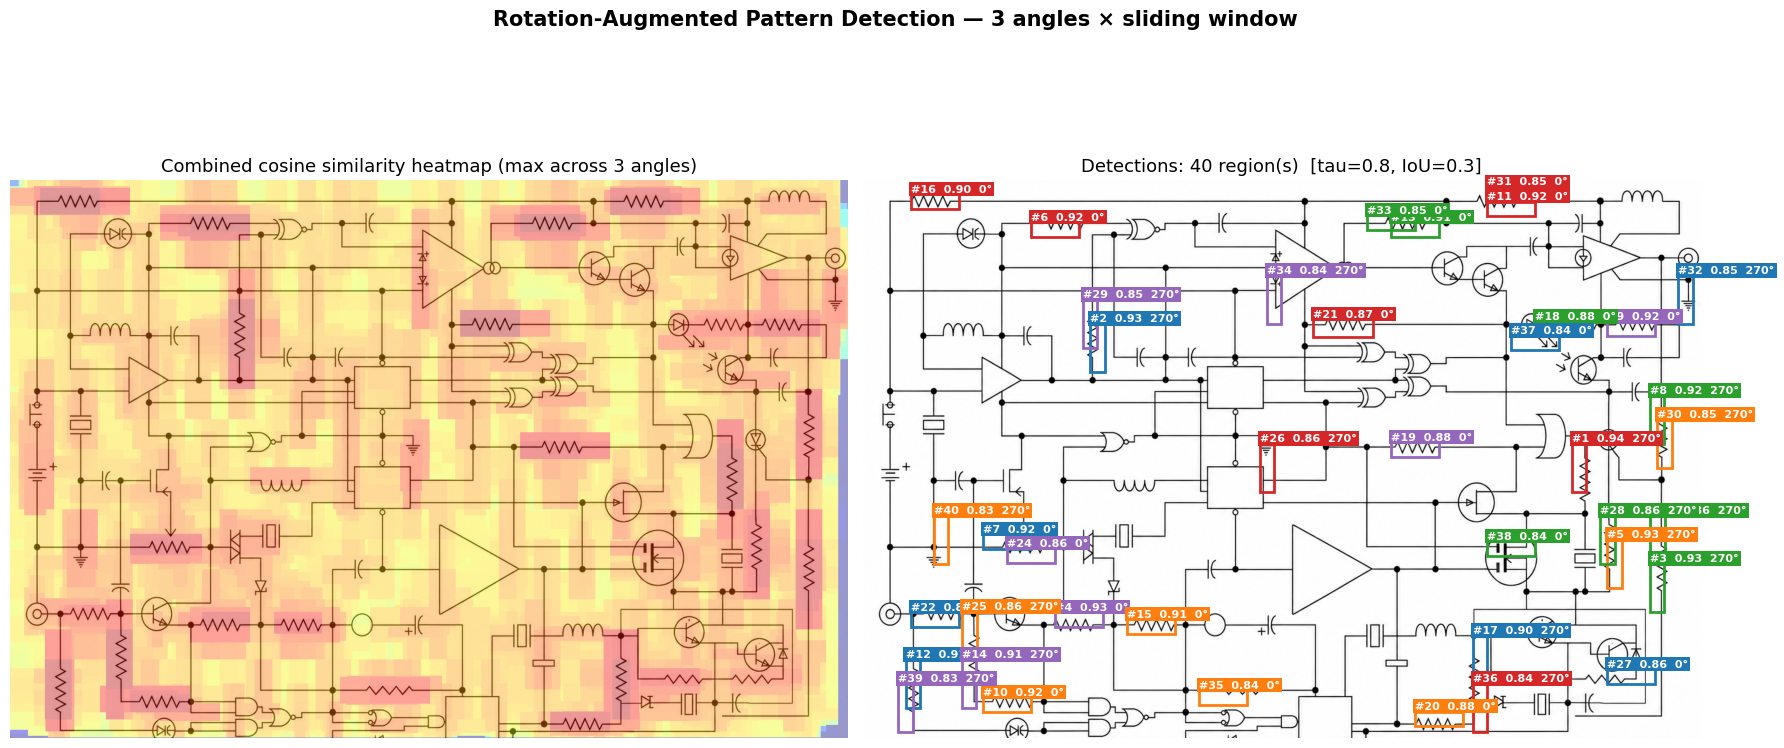

Saved -> detection_result.png


In [142]:
PALETTE = [
    (214/255,  39/255,  40/255),
    ( 31/255, 119/255, 180/255),
    ( 44/255, 160/255,  44/255),
    (148/255, 103/255, 189/255),
    (255/255, 127/255,  14/255),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].imshow(drawing_rgb)
axes[0].imshow(score_canvas, cmap='jet', alpha=0.40, vmin=0, vmax=1)
axes[0].set_title(f'Combined cosine similarity heatmap (max across {len(ROTATION_ANGLES)} angles)',
                  fontsize=13)
axes[0].axis('off')

axes[1].imshow(drawing_rgb)
for i, d in enumerate(detections):
    color = PALETTE[i % len(PALETTE)]
    x1, y1, x2, y2, score = d['x1'], d['y1'], d['x2'], d['y2'], d['score']
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    axes[1].add_patch(rect)
    angle_str = f'{d.get("angle", "?")}' + '°'
    axes[1].text(
        x1, max(y1 - 4, 0),
        f'#{i+1}  {score:.2f}  {angle_str}',
        color='white', fontsize=8, fontweight='bold',
        bbox=dict(facecolor=color, edgecolor='none', pad=1.5),
    )

axes[1].set_title(
    f'Detections: {len(detections)} region(s)  '
    f'[tau={SIMILARITY_THRESHOLD}, IoU={IOU_THRESHOLD}]', fontsize=13
)
axes[1].axis('off')

plt.suptitle(
    f'Rotation-Augmented Pattern Detection — {len(ROTATION_ANGLES)} angles × sliding window',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> detection_result.png')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

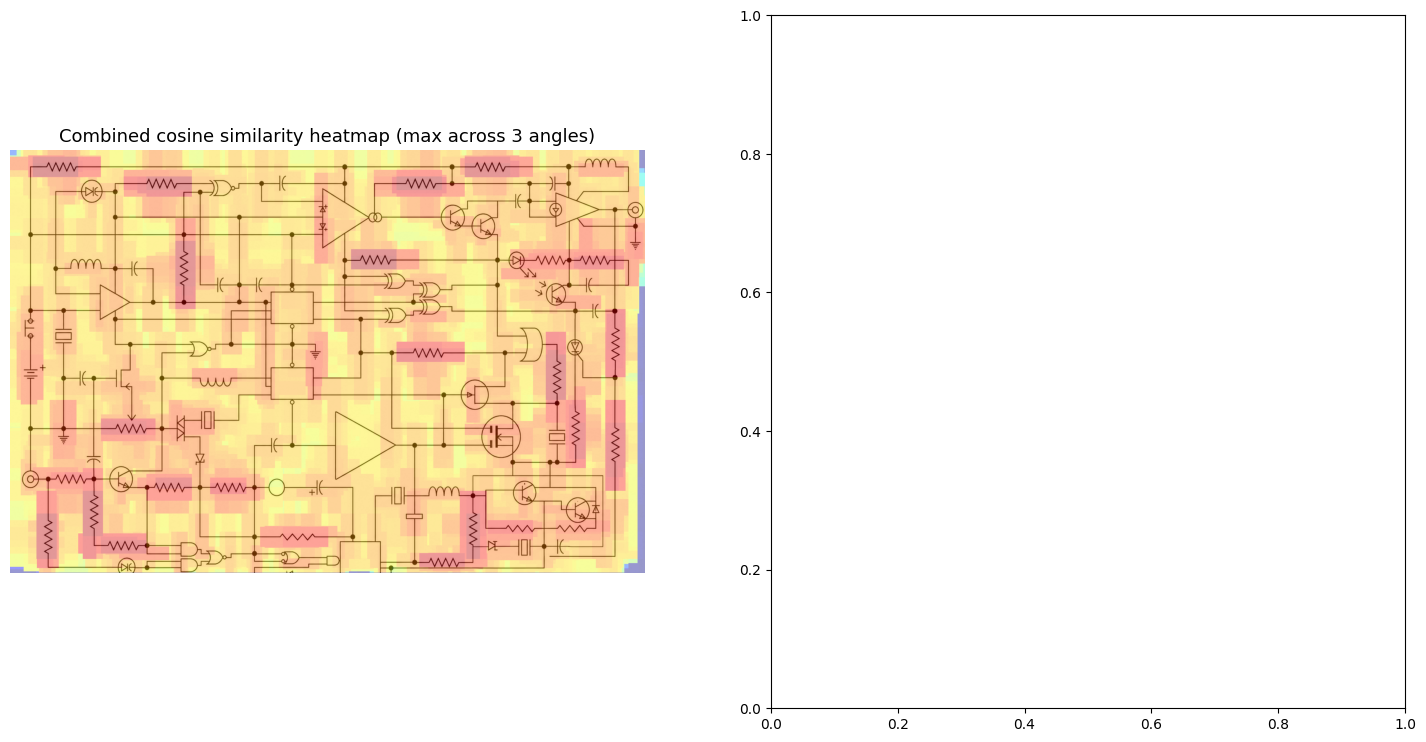

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(drawing_rgb)
axes[0].imshow(score_canvas, cmap='jet', alpha=0.40, vmin=0, vmax=1)
axes[0].set_title(f'Combined cosine similarity heatmap (max across {len(ROTATION_ANGLES)} angles)',
                  fontsize=13)
axes[0].axis('off')

In [144]:
output = {
    'bom_path'             : DRAWING_PATH,
    'pattern_path'         : PATTERN_PATH,
    'encoder'              : 'mobilenet_v3',
    'similarity_threshold' : SIMILARITY_THRESHOLD,
    'rotate pattern'       : ROTATE,
    'iou_threshold'        : IOU_THRESHOLD,
    'scales'               : SCALES,
    'stride_factor'        : STRIDE_FACTOR,
    'bom_size'             : {'height': target_h, 'width': target_w},
    'pattern_crop_size'    : {'height': pat_h, 'width': pat_w},
    'detections'           : detections,
}

with open('detections.json', 'w') as f:
    json.dump(output, f, indent=2)

print(json.dumps(output, indent=2))


{
  "bom_path": "./BOM_Data/4.png",
  "pattern_path": "./BOM_Data/Pattern4_2.png",
  "encoder": "mobilenet_v3",
  "similarity_threshold": 0.8,
  "rotate pattern": true,
  "iou_threshold": 0.3,
  "scales": [
    0.75,
    1.0,
    1.25
  ],
  "stride_factor": 0.5,
  "bom_size": {
    "height": 1024,
    "width": 1536
  },
  "pattern_crop_size": {
    "height": 27,
    "width": 88
  },
  "detections": [
    {
      "x1": 1300,
      "y1": 484,
      "x2": 1326,
      "y2": 572,
      "score": 0.9394,
      "angle": 270
    },
    {
      "x1": 416,
      "y1": 264,
      "x2": 443,
      "y2": 352,
      "score": 0.9326,
      "angle": 270
    },
    {
      "x1": 1443,
      "y1": 704,
      "x2": 1469,
      "y2": 792,
      "score": 0.9307,
      "angle": 270
    },
    {
      "x1": 352,
      "y1": 793,
      "x2": 440,
      "y2": 820,
      "score": 0.9266,
      "angle": 0
    },
    {
      "x1": 1365,
      "y1": 660,
      "x2": 1392,
      "y2": 748,
      "score": 0.926,
   